# Encoder and Random Forest and larger datasets

So far we have been limiting ourselves to single subsets of the data. A specfic instrument, ionization mode and what not. In this case I want to take several datasets, train them with different encoders then use a union of the outputs to train a much larger Random forest (ideally balaning that RF).

## Import packages

In [128]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

## Globally used Functions

In [92]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [93]:
# Binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [94]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [95]:
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

In [144]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"


## Data Processing: Upload, Edits, and Split

In [96]:
# The 5/20 dataset with rat based toxicity data
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()


# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# Data split based on the 'Group' column
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 

# With these there may not be enough data to train a model
df3_QQQpos = df3[df3['Group'] == 'QQQ-positive'] # 253
df3_QTOFneg = df3[df3['Group'] == 'Q-TOF-negative'] # 188
df3_QQQneg = df3[df3['Group'] == 'QQQ-negative'] # 85
df3_Opos = df3[df3['Group'] == 'Other-positive'] # 71
df3_LTQOneg = df3[df3['Group'] == 'LTQ-Orbitrap-negative'] # 63
df3_LTQpos = df3[df3['Group'] == 'LTQ-positive'] # 19
df3_QQQnan = df3[df3['Group'] == 'QQQ-nan'] # 18
df3_Oneg = df3[df3['Group'] == 'Other-negative'] # 13
df3_LTQneg = df3[df3['Group'] == 'LTQ-negative'] # 11

(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


## Data Processing: Binning

In [97]:
df3_QQpos_matrix = spectrum_string_to_dataframe(df3_QQpos,'Spectrum', 'SMILES_spectra')
df3_QQpos_spectra = df3_QQpos_matrix
df3_QQneg_matrix = spectrum_string_to_dataframe(df3_QQneg,'Spectrum', 'SMILES_spectra')
df3_QQneg_spectra = df3_QQneg_matrix
df3_QTOFpos_matrix = spectrum_string_to_dataframe(df3_QTOFpos,'Spectrum', 'SMILES_spectra')
df3_QTOFpos_spectra = df3_QTOFpos_matrix
df3_LTQOpos_matrix = spectrum_string_to_dataframe(df3_LTQOpos,'Spectrum', 'SMILES_spectra')
df3_LTQOpos_spectra = df3_LTQOpos_matrix

In [98]:
# Processing of the spectra to enable binning to work (consider changing this to a function)

# Conversion of m/z values to floats, keeping the first column (SMIELS) as is
# For df3_QQpos_spectra
cols = df3_QQpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQpos_spectra.columns = new_cols

# For df3_QQneg_spectra
cols = df3_QQneg_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQneg_spectra.columns = new_cols

# For df3_QTOFpos_spectra
cols = df3_QTOFpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QTOFpos_spectra.columns = new_cols

# For df3_LTQOpos_spectra
cols = df3_LTQOpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_LTQOpos_spectra.columns = new_cols


# Convert all elements except the first column to float
df3_QQpos_spectra.iloc[:, 1:] = df3_QQpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df3_QQneg_spectra.iloc[:, 1:] = df3_QQneg_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df3_QTOFpos_spectra.iloc[:, 1:] = df3_QTOFpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df3_LTQOpos_spectra.iloc[:, 1:] = df3_LTQOpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

all_float = all(isinstance(c, float) for c in df3_QQneg_spectra.columns[1:])
print("All columns are float:", all_float)
all_float = all(isinstance(c, float) for c in df3_QQpos_spectra.columns[1:])
print("All columns are float:", all_float)
all_float = all(isinstance(c, float) for c in df3_QTOFpos_spectra.columns[1:])
print("All columns are float:", all_float)
all_float = all(isinstance(c, float) for c in df3_LTQOpos_spectra.columns[1:])
print("All columns are float:", all_float)

# Check if every element is a float
spectra = df3_QQpos_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)
spectra = df3_QQneg_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)
spectra = df3_QTOFpos_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)
spectra = df3_LTQOpos_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

# Sort columns by float value, keep the first column (SMILES) first
cols = df3_QQpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QQpos_spectra = df3_QQpos_spectra[sorted_cols]
cols = df3_QQneg_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QQneg_spectra = df3_QQneg_spectra[sorted_cols]
cols = df3_QTOFpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QTOFpos_spectra = df3_QTOFpos_spectra[sorted_cols]
cols = df3_LTQOpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_LTQOpos_spectra = df3_LTQOpos_spectra[sorted_cols]

All columns are float: True
All columns are float: True
All columns are float: True
All columns are float: True
All elements are float: True
All elements are float: True
All elements are float: True
All elements are float: True


In [99]:
df3_QTOFpos_spectra.head()

,SMILES_spectra,29.0112,30.032,30.0323,31.01686,31.54035,38.5076,39.0214,39.0215,39.02194,...,1879.890381,1881.465942,1890.796509,1894.779541,1939.240845,1965.805054,1966.380615,1982.848389,2000.461914,2000.942627
30,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [100]:
# Use the binning function 
# On df3_QQpos_spectra
binned_df3_QQpos_spectra = bin_spectra_by_integer_mz(df3_QQpos_spectra)
binned_df3_QQpos_spectra_filled = fill_missing_integer_columns(binned_df3_QQpos_spectra)

# On df3_QQpos_spectra
binned_df3_QQneg_spectra = bin_spectra_by_integer_mz(df3_QQneg_spectra)
binned_df3_QQneg_spectra_filled = fill_missing_integer_columns(binned_df3_QQneg_spectra)

# On df3_QQpos_spectra
binned_df3_QTOFpos_spectra = bin_spectra_by_integer_mz(df3_QTOFpos_spectra)
binned_df3_QTOFpos_spectra_filled = fill_missing_integer_columns(binned_df3_QTOFpos_spectra)

# On df3_LTQOpos_spectra
binned_df3_LTQOpos_spectra = bin_spectra_by_integer_mz(df3_LTQOpos_spectra)
binned_df3_LTQOpos_spectra_filled = fill_missing_integer_columns(binned_df3_LTQOpos_spectra)

/tmp/ipykernel_363101/339873635.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  binned.insert(0, smiles_col, df[smiles_col])
/tmp/ipykernel_363101/339873635.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0.0
/tmp/ipykernel_363101/339873635.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fra

In [101]:
print(binned_df3_QQpos_spectra_filled.shape)
print(binned_df3_QQneg_spectra_filled.shape)
print(binned_df3_QTOFpos_spectra_filled.shape)
print(binned_df3_LTQOpos_spectra_filled.shape)

(1307, 680)
(756, 493)
(736, 2002)
(481, 816)


In [102]:
# # Save the binned spectra to a CSV file
# binned_df3_QQpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv", index=False)
# binned_df3_QQneg_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv", index=False)
# binned_df3_QTOFpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv", index=False)
# binned_df3_LTQOpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv", index=False)

## ChemNet True Embeddings

In [103]:
ChemNet_of_df3_QQpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QQpos_spectra["SMILES_spectra"])
ChemNet_of_df3_QQneg_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QQneg_spectra["SMILES_spectra"])
ChemNet_of_df3_QTOFpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QTOFpos_spectra["SMILES_spectra"])
ChemNet_of_df3_LTQOpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_LTQOpos_spectra["SMILES_spectra"])

/home/dlipsey/.local/lib/python3.8/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(model_path)


In [104]:
# Making the ChemNet embeddings into a dataframes
# For df3_QQpos
ChemNet_of_df3_QQpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QQpos_no_repeats_dict, orient='index')
ChemNet_of_df3_QQpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QQpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

# For df3_QQneg
ChemNet_of_df3_QQneg_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QQneg_no_repeats_dict, orient='index')
ChemNet_of_df3_QQneg_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QQneg_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

# For df3_QTOFpos
ChemNet_of_df3_QTOFpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QTOFpos_no_repeats_dict, orient='index')
ChemNet_of_df3_QTOFpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QTOFpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

# For df3_LTQOpos
ChemNet_of_df3_LTQOpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_LTQOpos_no_repeats_dict, orient='index')
ChemNet_of_df3_LTQOpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_LTQOpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

In [105]:
# # Save ChemNet embeddings to a CSV file
# ChemNet_of_df3_QQpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv", index=False)
# ChemNet_of_df3_QQneg_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQneg_no_repeats.csv", index=False)
# ChemNet_of_df3_QTOFpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv", index=False)
# ChemNet_of_df3_LTQOpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv", index=False)

## Encoder Implementation

### Encoder architecture

In [106]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 10

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


## Implementation of the encoder on df3_QQpos

In [107]:
# Training and validation dataset split for the positive ionization mode
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQpos = train_data.copy()

# Make a copy
train_data_df3_QQpos = train_data.copy()
test_data_df3_QQpos = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 



(609, 681)
(579, 681)


In [108]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQpos = train_model(
    model=encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQpos = x_val
x_train_df3_QQpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22760.0 MB
  Memory Used: 1457.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.0890714019536972
   Validation loss: 0.014718773774802685
Epoch [2/500]
   Training loss: 0.08134299963712692
   Validation loss: 0.013972820714116096
Epoch [3/500]
   Training loss: 0.07137445881962776
   Validation loss: 0.011883432976901531
Epoch [4/500]
   Training loss: 0.06661134958267212
   Validation loss: 0.011796962469816208
Epoch [5/500]
   Training loss: 0.06440286450088024
   Validation loss: 0.011195271275937557
Epoch [6/500]
   Training loss: 0.06404984667897225
   Validation loss: 0.011545374989509583
Epoch [7/500]
   Training loss: 0.06360817141830921
   Validation loss: 0.011163248680531979
Epoch [8/500]
   Training loss: 0.06333480961620808
   Validation loss: 0.010955589823424816
Epoch [9/500]
   Training lo

## Implementation of the encoder on df3_QQneg

In [109]:
# Training and validation dataset split 
df3_QQneg_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQneg_no_repeats.csv")

# Generalize the syntax
dataset =  df3_QQneg_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQneg = train_data.copy()

# Make a copy
train_data_df3_QQneg = train_data.copy()
test_data_df3_QQneg = test_data.copy()
# Load val_data 
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(359, 494)
(342, 494)


In [110]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQneg = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQneg = train_model(
    model=encoder_df3_QQneg,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQneg = x_val
x_train_df3_QQneg = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22760.0 MB
  Memory Used: 1457.0 MB
  GPU Load: 5.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.09104607999324799
   Validation loss: 0.02847173810005188
Epoch [2/500]
   Training loss: 0.08890748769044876
   Validation loss: 0.02797379158437252
Epoch [3/500]
   Training loss: 0.08322492490212123
   Validation loss: 0.025334646925330162
Epoch [4/500]
   Training loss: 0.0753737526635329
   Validation loss: 0.023918120190501213
Epoch [5/500]
   Training loss: 0.068691311404109
   Validation loss: 0.021106712520122528
Epoch [6/500]
   Training loss: 0.0651302548746268
   Validation loss: 0.02100241929292679
Epoch [7/500]
   Training loss: 0.06296605865160625
   Validation loss: 0.020661238580942154
Epoch [8/500]
   Training loss: 0.06173980049788952
   Validation loss: 0.019756263121962547
Epoch [9/500]
   Training loss: 0.

## Implementation of the encoder on df3_QTOFpos

In [111]:
# Training and validation dataset split 
df3_QTOFpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv")

# Generalize the syntax
dataset =  df3_QTOFpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQneg = train_data.copy()

# Make a copy
train_data_df3_QTOFpos = train_data.copy()
test_data_df3_QTOFpos = test_data.copy() 
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 


(330, 2003)
(308, 2003)


In [112]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QTOFpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QTOFpos = train_model(
    model=encoder_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QTOFpos = x_val
x_train_df3_QTOFpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22728.0 MB
  Memory Used: 1489.0 MB
  GPU Load: 6.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.0865558534860611
   Validation loss: 0.028546107932925224
Epoch [2/500]
   Training loss: 0.08107904965678851
   Validation loss: 0.027023762464523315
Epoch [3/500]
   Training loss: 0.07260778297980626
   Validation loss: 0.02520444057881832
Epoch [4/500]
   Training loss: 0.06742104142904282
   Validation loss: 0.02523776888847351
Epoch [5/500]
   Training loss: 0.06464928078154723
   Validation loss: 0.022839529439806938
Epoch [6/500]
   Training loss: 0.06345590017735958
   Validation loss: 0.022708341479301453
Epoch [7/500]
   Training loss: 0.06380362994968891
   Validation loss: 0.02471090294420719
Epoch [8/500]
   Training loss: 0.06442907266318798
   Validation loss: 0.02502289228141308
Epoch [9/500]
   Training loss: 

## Implementation of the encoder on df3_LTQOpos

In [113]:
# Training and validation dataset split 
df3_LTQOpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv")

# Generalize the syntax
dataset = df3_LTQOpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_LTQOpos = train_data.copy()
test_data_df3_LTQOpos = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 


(239, 817)
(233, 817)


In [114]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_LTQOpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_LTQOpos = train_model(
    model=encoder_df3_LTQOpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

x_val_df3_LTQOpos = x_val
x_train_df3_LTQOpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22472.0 MB
  Memory Used: 1745.0 MB
  GPU Load: 27.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.08739031292498112
   Validation loss: 0.04047340154647827
Epoch [2/500]
   Training loss: 0.08589801751077175
   Validation loss: 0.03897854685783386
Epoch [3/500]
   Training loss: 0.08377837017178535
   Validation loss: 0.03785053640604019
Epoch [4/500]
   Training loss: 0.0786752887070179
   Validation loss: 0.03574461489915848
Epoch [5/500]
   Training loss: 0.07266858965158463
   Validation loss: 0.03173476457595825
Epoch [6/500]
   Training loss: 0.06772409193217754
   Validation loss: 0.02929331362247467
Epoch [7/500]
   Training loss: 0.06455919332802296
   Validation loss: 0.02838536724448204
Epoch [8/500]
   Training loss: 0.06249318365007639
   Validation loss: 0.028246529400348663
Epoch [9/500]
   Training loss: 0.

## Encoder Testing

In [118]:
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQneg
encoder_df3_QQneg.eval()
with torch.no_grad():
    test_output_df3_QQneg = encoder_df3_QQneg(x_val_df3_QQneg)  

with torch.no_grad():
    train_output_df3_QQneg = encoder_df3_QQneg(x_train_df3_QQneg)  

# Encoder excecution df3_QTOFpos
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_val_df3_QTOFpos)  

with torch.no_grad():
    train_output_df3_QTOFpos = encoder_df3_QTOFpos(x_train_df3_QTOFpos)

# Encoder excecution df3_LTQOpos
encoder_df3_LTQOpos.eval()
with torch.no_grad():
    test_output_df3_LTQOpos = encoder_df3_LTQOpos(x_val_df3_LTQOpos)  

with torch.no_grad():
    train_output_df3_LTQOpos = encoder_df3_LTQOpos(x_train_df3_LTQOpos)  

## Encoder output data processing

In [119]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()
test_output_df3_QQneg_np = test_output_df3_QQneg.cpu().numpy()
train_output_df3_QQneg_np = train_output_df3_QQneg.cpu().numpy()
test_output_df3_QTOFpos_np = test_output_df3_QTOFpos.cpu().numpy()
train_output_df3_QTOFpos_np = train_output_df3_QTOFpos.cpu().numpy()
test_output_df3_LTQOpos_np = test_output_df3_LTQOpos.cpu().numpy()
train_output_df3_LTQOpos_np = train_output_df3_LTQOpos.cpu().numpy()
# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])
test_output_df3_QQneg = pd.DataFrame(test_output_df3_QQneg_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQneg_np.shape[1])])
train_output_df3_QQneg = pd.DataFrame(train_output_df3_QQneg_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQneg_np.shape[1])])
test_output_df3_QTOFpos = pd.DataFrame(test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QTOFpos_np.shape[1])])
train_output_df3_QTOFpos = pd.DataFrame(train_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QTOFpos_np.shape[1])])
test_output_df3_LTQOpos = pd.DataFrame(test_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_LTQOpos_np.shape[1])])
train_output_df3_LTQOpos = pd.DataFrame(train_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_LTQOpos_np.shape[1])])
# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos['SMILES_spectra']
test_output_df3_QQneg['SMILES_spectra'] = test_data_df3_QQneg['SMILES_spectra']
train_output_df3_QQneg['SMILES_spectra'] = train_data_df3_QQneg['SMILES_spectra']
test_output_df3_QTOFpos['SMILES_spectra'] = test_data_df3_QTOFpos['SMILES_spectra']
train_output_df3_QTOFpos['SMILES_spectra'] = train_data_df3_QTOFpos['SMILES_spectra']
test_output_df3_LTQOpos['SMILES_spectra'] = test_data_df3_LTQOpos['SMILES_spectra']
train_output_df3_LTQOpos['SMILES_spectra'] = train_data_df3_LTQOpos['SMILES_spectra']

In [120]:
# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Example usage for each output DataFrame:
test_output_df3_QQpos = add_response_column(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_column(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

test_output_df3_QQneg = add_response_column(test_output_df3_QQneg, df3_QQneg, smiles_col='SMILES_spectra')
train_output_df3_QQneg = add_response_column(train_output_df3_QQneg, df3_QQneg, smiles_col='SMILES_spectra')

test_output_df3_QTOFpos = add_response_column(test_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
train_output_df3_QTOFpos = add_response_column(train_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')

test_output_df3_LTQOpos = add_response_column(test_output_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')
train_output_df3_LTQOpos = add_response_column(train_output_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')


In [121]:
train_output_df3_LTQOpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 505,Embedding Float 506,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response
0,-0.161753,-0.000728,-0.008221,0.099124,-0.103705,0.189976,-0.266247,-0.092564,-0.101921,0.273803,...,0.112591,8.940697e-07,-0.303639,-0.004314,0.029431,-0.138795,0.020386,-0.077527,C1CCC(CC1)NC1CCCCC1,373.0
1,-0.160470,0.000369,-0.006366,0.100154,-0.102049,0.186598,-0.266092,-0.092978,-0.104228,0.269891,...,0.112021,-9.339824e-04,-0.298306,-0.006523,0.026178,-0.137374,0.020161,-0.079431,C1CCC(CC1)NC1CCCCC1,373.0
2,-0.162285,0.001105,-0.007869,0.102536,-0.105049,0.189829,-0.265923,-0.094237,-0.101708,0.276347,...,0.112521,1.721449e-03,-0.303904,-0.006669,0.028834,-0.140393,0.020426,-0.080278,C1CCC(CC1)NC1CCCCC1,373.0
3,-0.162452,-0.000772,-0.007498,0.098840,-0.103185,0.190034,-0.267498,-0.092950,-0.102584,0.273603,...,0.111926,4.220307e-04,-0.303693,-0.004040,0.028547,-0.139307,0.019880,-0.078340,C1CCC(CC1)NC1CCCCC1,373.0
4,-0.162114,0.001173,-0.006989,0.097651,-0.102110,0.189989,-0.268597,-0.094277,-0.102132,0.271623,...,0.108652,1.857683e-03,-0.302042,-0.006751,0.027384,-0.140218,0.017833,-0.079640,C1CCC(CC1)NC1CCCCC1,373.0


In [ ]:
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    # Assign EPA levels
    df["EPA_level"] = df[response_col].apply(assign_func)
    # One-hot encode
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    # Convert boolean columns to int
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    # Remove the Response column
    df.drop(columns=[response_col], inplace=True)
    return df

# Example usage for all your DataFrames:
test_output_df3_QQpos_withEPA = add_epa_levels(test_output_df3_QQpos)
train_output_df3_QQpos_withEPA = add_epa_levels(train_output_df3_QQpos)

test_output_df3_QQneg_withEPA = add_epa_levels(test_output_df3_QQneg)
train_output_df3_QQneg_withEPA = add_epa_levels(train_output_df3_QQneg)

test_output_df3_QTOFpos_withEPA = add_epa_levels(test_output_df3_QTOFpos)
train_output_df3_QTOFpos_withEPA = add_epa_levels(train_output_df3_QTOFpos)

test_output_df3_LTQOpos_withEPA = add_epa_levels(test_output_df3_LTQOpos)
train_output_df3_LTQOpos_withEPA = add_epa_levels(train_output_df3_LTQOpos)

(579, 517)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,-0.228839,0.003153,0.282220,0.426838,-0.114898,0.092664,-0.234281,-0.207396,-0.225335,-0.047594,...,0.226269,-0.331135,0.391917,0.341193,0.062620,C#CCN(C)Cc1ccccc1,0,1,0,0
1,-0.113766,0.005080,0.001281,0.388158,-0.037644,0.137270,-0.054840,-0.533982,-0.587838,-0.434670,...,-0.161466,-0.527643,0.137191,0.111724,0.229136,C#CCN(C)Cc1ccccc1,0,1,0,0
2,-0.195886,-0.007614,0.118415,0.352394,-0.041320,0.141112,-0.112923,-0.385637,-0.459181,-0.301011,...,-0.030050,-0.487911,0.259458,0.222770,0.181085,C#CCN(C)Cc1ccccc1,0,1,0,0
3,0.323776,0.002528,0.133477,0.679808,-0.127385,0.107393,-0.423492,-0.031152,-0.004479,0.065268,...,0.192862,0.337092,0.585256,0.134026,0.405499,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0,0,1,0
4,-0.097239,0.016541,0.455237,0.825933,-0.130091,0.067778,-0.276037,-0.079040,-0.008131,0.001328,...,0.308940,-0.039189,0.449368,0.411250,0.070172,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0,0,1,0


In [126]:
# Make the dataframes that we will use a train set, a test set, and a combined set
train_concat = pd.concat([
    train_output_df3_QQpos_withEPA,
    train_output_df3_QQneg_withEPA,
    train_output_df3_QTOFpos_withEPA,
    train_output_df3_LTQOpos_withEPA
], ignore_index=True)

test_concat = pd.concat([
    test_output_df3_QQpos_withEPA,
    test_output_df3_QQneg_withEPA,
    test_output_df3_QTOFpos_withEPA,
    test_output_df3_LTQOpos_withEPA
], ignore_index=True)

combined_concat = pd.concat([train_concat, test_concat], ignore_index=True)

print("Train shape:", train_concat.shape)
print("Test shape:", test_concat.shape)
print("Combined shape:", combined_concat.shape)

Train shape: (1537, 517)
Test shape: (1462, 517)
Combined shape: (2999, 517)


## Random Forest on Data

### 4 way classifiers

In [130]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_concat.columns
    if col not in ['SMILES'] + [col for col in test_concat.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_concat.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [131]:
# Training of an untuned and unbalanced Random Forest Classifier
X = test_concat[embedding_cols]
y = test_concat[epa_level_cols].idxmax(axis=1)  # e.g., 'EPA_level_2'

# Split into train/test (optional, since this is already a test set, but for demonstration)
X.columns = X.columns.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Remove any non-numeric columns from X
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Train Random Forest
rf_utub = RandomForestClassifier(n_estimators=100, random_state=47)
# Convert all column names to strings
rf_utub.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_utub.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[  7   0   1   0]
 [  0  38  25   0]
 [  0   3 154   3]
 [  0   1  26  35]]


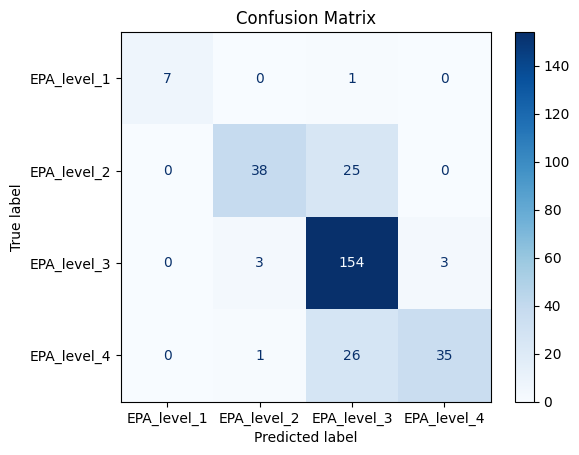

In [132]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [137]:
# Prepare features (X) and labels (y) as before
X = test_concat[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_concat[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 100
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
print(confusion_matrix(y_test_bal, y_pred_bal))

[[20  0  0  0]
 [ 1 11  4  4]
 [ 0  1 16  3]
 [ 1  1  3 15]]


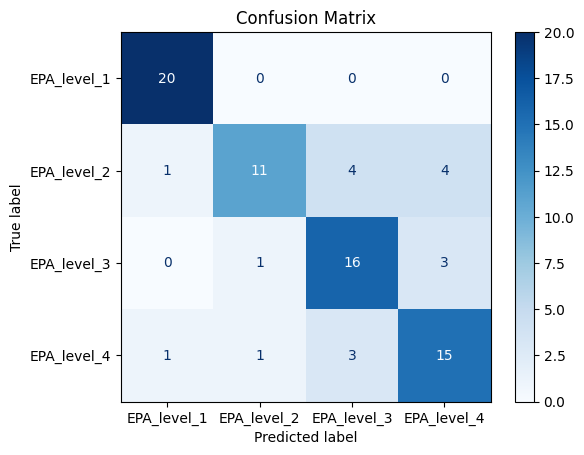

In [138]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

### 2 way classifiers

In [141]:
# Create new binary label
def combine_epa_levels(row):
    if row.get('EPA_level_1', 0) == 1 or row.get('EPA_level_2', 0) == 1:
        return 'EPA_level_1_2'
    elif row.get('EPA_level_4', 0) == 1:
        return 'EPA_level_4'
    else:
        return None  

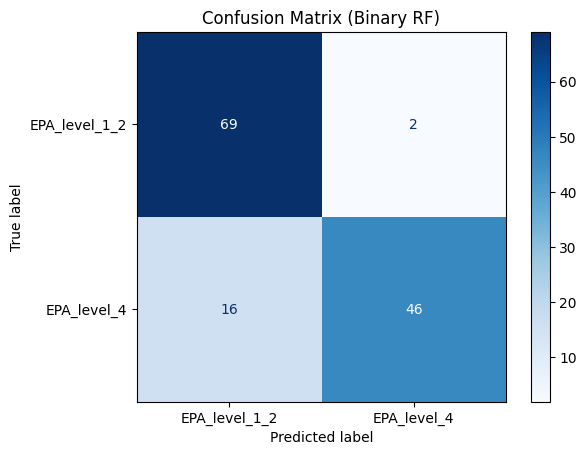

In [142]:
# Binary Classification untuned and unbalanced Random Forest Classifier
df_bin = test_concat.copy()
df_bin['EPA_binary'] = df_bin.apply(combine_epa_levels, axis=1)
df_bin = df_bin[df_bin['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

embedding_cols_bin = [
    col for col in df_bin.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_binary'] and not str(col).startswith('EPA_level_')
]
X_bin = df_bin[embedding_cols_bin].select_dtypes(include=[np.number])
X_bin.columns = X_bin.columns.astype(str)
y_bin = df_bin['EPA_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

rf_bin = RandomForestClassifier(n_estimators=100, random_state=47)
rf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = rf_bin.predict(X_test_bin)

cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin.plot(cmap='Blues')
plt.title("Confusion Matrix (Binary RF)")
plt.show()

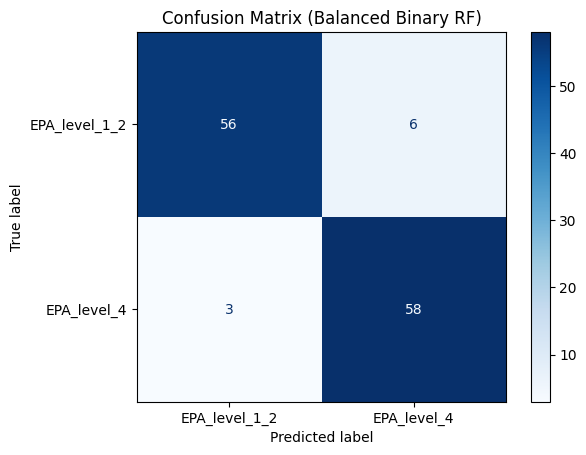

In [ ]:
# Balanced Binary Classification
# Set up sampling strategy
target_count = 100
# Undersample the majority class
rus = RandomUnderSampler(sampling_strategy='auto', random_state=15)
X_under, y_under = rus.fit_resample(X_bin, y_bin)
# Oversample the minority class
ros = RandomOverSampler(sampling_strategy='auto', random_state=15)
X_bal, y_bal = ros.fit_resample(X_under, y_under)

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=15, stratify=y_bal
)

rf_bin_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bin_bal.fit(X_train_bal, y_train_bal)
y_pred_bal = rf_bin_bal.predict(X_test_bal)

cm_bal = confusion_matrix(y_test_bal, y_pred_bal, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bal.plot(cmap='Blues')
plt.title("Confusion Matrix (Balanced Binary RF)")
plt.show()

### Three way classifiers

In [ ]:
# Function to assign 3 EPA levels
def combine_epa_levels_3way(row):
    if row.get('EPA_level_1', 0) == 1 or row.get('EPA_level_2', 0) == 1:
        return 'EPA_level_1_2'
    elif row.get('EPA_level_3', 0) == 1:
        return 'EPA_level_3'
    elif row.get('EPA_level_4', 0) == 1:
        return 'EPA_level_4'
    else:
        return None

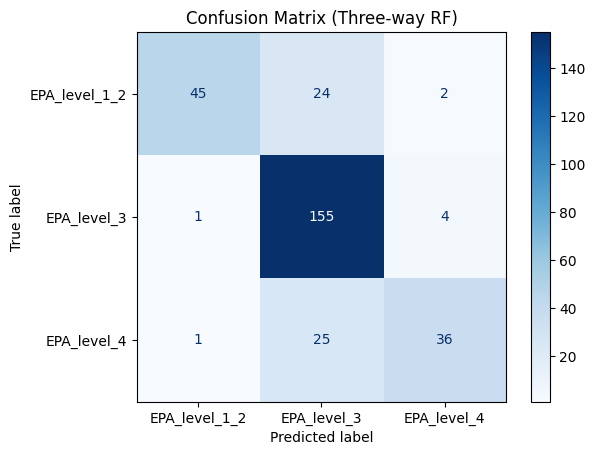

In [ ]:
# Three-way classification untuned and unbalanced Random Forest Classifier
df_3way = test_concat.copy()
df_3way['EPA_3way'] = df_3way.apply(combine_epa_levels_3way, axis=1)
df_3way = df_3way[df_3way['EPA_3way'].isin(['EPA_level_1_2', 'EPA_level_3', 'EPA_level_4'])].copy()

embedding_cols_3way = [
    col for col in df_3way.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_3way'] and not str(col).startswith('EPA_level_')
]
X_3way = df_3way[embedding_cols_3way].select_dtypes(include=[np.number])
X_3way.columns = X_3way.columns.astype(str)
y_3way = df_3way['EPA_3way']

# Train/test split
X_train_3way, X_test_3way, y_train_3way, y_test_3way = train_test_split(
    X_3way, y_3way, test_size=0.2, random_state=42, stratify=y_3way
)

rf_3way = RandomForestClassifier(n_estimators=100, random_state=47)
rf_3way.fit(X_train_3way, y_train_3way)
y_pred_3way = rf_3way.predict(X_test_3way)

labels_3way = ['EPA_level_1_2', 'EPA_level_3', 'EPA_level_4']
cm_3way = confusion_matrix(y_test_3way, y_pred_3way, labels=labels_3way)
disp_3way = ConfusionMatrixDisplay(confusion_matrix=cm_3way, display_labels=labels_3way)
disp_3way.plot(cmap='Blues')
plt.title("Confusion Matrix (Three-way RF)")
plt.show()

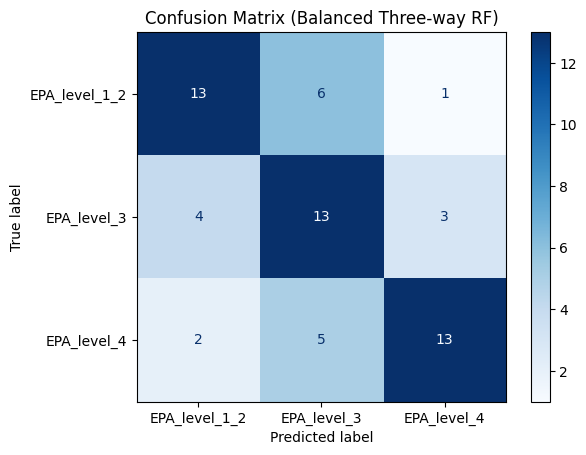

In [147]:
# Balanced Three-way Classification: EPA_level_1_2, EPA_level_3, EPA_level_4
# Set up sampling strategy
target_count = 100
class_counts_3way = dict(Counter(y_3way))
sampling_strategy_3way = {cls: min(target_count, class_counts_3way[cls]) for cls in class_counts_3way}
# Undersample the majority classes
rus_3way = RandomUnderSampler(sampling_strategy=sampling_strategy_3way, random_state=15)
X_under_3way, y_under_3way = rus_3way.fit_resample(X_3way, y_3way)
# Oversample the minority classes
sampling_strategy_3way = {cls: target_count for cls in class_counts_3way}
ros_3way = RandomOverSampler(sampling_strategy=sampling_strategy_3way, random_state=15)
X_bal_3way, y_bal_3way = ros_3way.fit_resample(X_under_3way, y_under_3way)

# Train/test split
X_train_bal_3way, X_test_bal_3way, y_train_bal_3way, y_test_bal_3way = train_test_split(
    X_bal_3way, y_bal_3way, test_size=0.2, random_state=15, stratify=y_bal_3way
)

rf_3way_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_3way_bal.fit(X_train_bal_3way, y_train_bal_3way)
y_pred_bal_3way = rf_3way_bal.predict(X_test_bal_3way)

labels_3way = ['EPA_level_1_2', 'EPA_level_3', 'EPA_level_4']
cm_bal_3way = confusion_matrix(y_test_bal_3way, y_pred_bal_3way, labels=labels_3way)
disp_bal_3way = ConfusionMatrixDisplay(confusion_matrix=cm_bal_3way, display_labels=labels_3way)
disp_bal_3way.plot(cmap='Blues')
plt.title("Confusion Matrix (Balanced Three-way RF)")
plt.show()